In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/content/train.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Data Types:
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Missing Values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [7]:
print("SalePrice statistics:")
print(y.describe())


SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [8]:
# Separate numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 37
Categorical features: 43


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 80)
Testing features: (292, 80)
Training target: (1168,)
Testing target: (292,)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model 1: Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Model 2: Random Forest Regressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Model 3: Gradient Boosting Regressor
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

# Train all three models
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All 3 models trained successfully.")

All 3 models trained successfully.


## Model Training

Three regression models are trained and compared:
1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Each model uses the same preprocessing pipeline and the same training/testing split to ensure a fair comparison.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    }

# Evaluate all models
results = [
    evaluate_model('Linear Regression', y_test, y_pred_linear),
    evaluate_model('Random Forest', y_test, y_pred_rf),
    evaluate_model('Gradient Boosting', y_test, y_pred_gb)
]

comparison_df = pd.DataFrame(results)

comparison_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,20485.659297,31327.795381,0.872048
1,Random Forest,17494.262637,28480.779436,0.894248
2,Gradient Boosting,17029.796779,27553.814148,0.901020


### Model Comparison

The three regression models are compared using MAE, RMSE, and R² Score. The model with the lowest prediction errors and highest R² Score will be considered the best-performing model on the test dataset.

In [13]:
# Select the best model based on the lowest RMSE
best_model_name = comparison_df.loc[
    comparison_df['RMSE'].idxmin(), 'Model'
]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


## Best Model Analysis

The best-performing model is selected based on the evaluation results. A lower RMSE indicates smaller prediction errors, while a higher R² Score indicates better model performance.

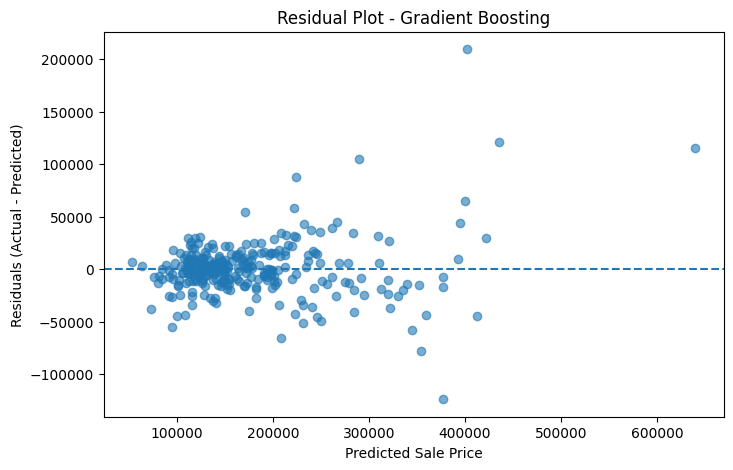

In [14]:
import matplotlib.pyplot as plt

# Select predictions of the best model
predictions = {
    'Linear Regression': y_pred_linear,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

best_predictions = predictions[best_model_name]

# Calculate residuals
residuals = y_test - best_predictions

# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')

plt.title(f'Residual Plot - {best_model_name}')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

## Final Conclusion

Three regression models were trained and evaluated: Linear Regression, Random Forest, and Gradient Boosting.

Based on the evaluation metrics, Gradient Boosting performed the best among the three models, achieving the lowest RMSE and strong R² performance. This indicates that it was the most effective model for predicting house sale prices in this dataset.

The residual plot was used to analyze the prediction errors of the best model. Overall, Gradient Boosting was selected as the final model for the House Prices prediction task.